In [78]:
!pip install pynwb

In [79]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x137327135676928
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [80]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x137328020798160
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [81]:
units = nwbfile.units

print(units.colnames)

('heldout', 'spike_times', 'obs_intervals')


In [82]:
import numpy as np
import matplotlib.pyplot as plt

In [83]:
spike_times = units['spike_times'][0]

print(spike_times[:20])

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]


In [84]:
# 1. Define your bin size (e.g., 20 ms = 0.02 seconds)
bin_size = 0.02 

start_time = 0.0
end_time = np.max(spike_times) + bin_size
bins = np.arange(start_time, end_time, bin_size)

# 3. Bin the spike times
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [85]:
print("Spike counts around 2.7 seconds:")
print(spike_counts[130:150])

print("\nFiring rates (Hz) around 2.7 seconds:")
print(firing_rate[130:150])

Spike counts around 2.7 seconds:
[0 0 0 0 1 0 0 2 2 0 1 0 0 1 0 0 0 0 0 0]

Firing rates (Hz) around 2.7 seconds:
[  0.   0.   0.   0.  50.   0.   0. 100. 100.   0.  50.   0.   0.  50.
   0.   0.   0.   0.   0.   0.]


In [86]:
first_active_bin = np.where(spike_counts > 0)[0][0]
print(f"First active bin index: {first_active_bin}")
print(f"Spike counts starting from there: {spike_counts[first_active_bin:first_active_bin+10]}")

First active bin index: 134
Spike counts starting from there: [1 0 0 2 2 0 1 0 0 1]


In [87]:
def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    
    # 1. Find the global max time across all units to standardize the matrix size
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    # 2. Define standard bin edges
    start_time = 0.0
    end_time = global_max_time + bin_size
    bins = np.arange(start_time, end_time, bin_size)
    num_bins = len(bins) - 1
    
    # 3. Initialize the population matrix: (Bins x Units)
    population_matrix = np.zeros((num_bins, num_units))
    
    # 4. Fill the matrix unit by unit
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

# Bin the training data you currently have open
train_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.02)

print(f"Population matrix shape (Bins x Units): {train_matrix.shape}")
print(f"Total number of recorded neural units: {train_matrix.shape[1]}")

Population matrix shape (Bins x Units): (240467, 54)
Total number of recorded neural units: 54


In [88]:
# 1. Define the path to your test NWB file
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# 2. Load the test file
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# 3. Bin the test data using the exact same function and bin size
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)

print(f"Train matrix shape: {train_matrix.shape} (Bins x Units)")
print(f"Test matrix shape:  {test_matrix.shape} (Bins x Units)")

Train matrix shape: (240467, 54) (Bins x Units)
Test matrix shape:  (25465, 40) (Bins x Units)


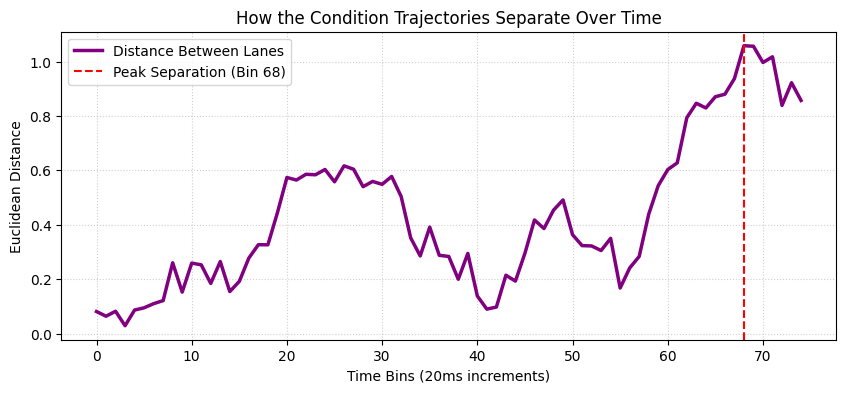

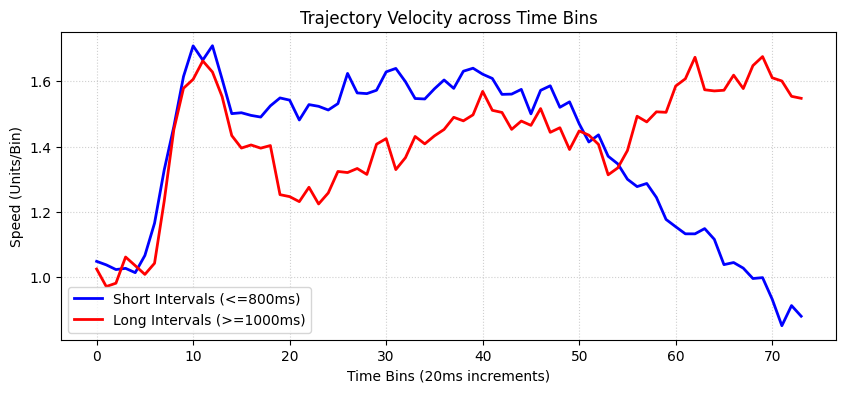

In [89]:
import matplotlib.pyplot as plt

# 1. Plot the Separation Distance between Conditions over Time
plt.figure(figsize=(10, 4))
plt.plot(distances, color='purple', linewidth=2.5, label='Distance Between Lanes')
plt.axvline(x=68, color='red', linestyle='--', label='Peak Separation (Bin 68)')

plt.xlabel('Time Bins (20ms increments)')
plt.ylabel('Euclidean Distance')
plt.title('How the Condition Trajectories Separate Over Time')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

# 2. Plot the Speeds (Velocity) comparison side-by-side
plt.figure(figsize=(10, 4))
plt.plot(short_speeds, color='blue', linewidth=2, label='Short Intervals (<=800ms)')
plt.plot(long_speeds, color='red', linewidth=2, label='Long Intervals (>=1000ms)')

plt.xlabel('Time Bins (20ms increments)')
plt.ylabel('Speed (Units/Bin)')
plt.title('Trajectory Velocity across Time Bins')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

In [90]:
# Convert the training trials table to a pandas DataFrame for easy viewing
train_trials_df = nwbfile.intervals['trials'].to_dataframe()

print(f"Total trials in training set: {len(train_trials_df)}")
print("\nFirst 5 rows of the trials table:")
train_trials_df.head()

Total trials in training set: 1160

First 5 rows of the trials table:


,start_time,stop_time,fix_on_time,fix_time,target_on_time,ready_time,set_time,go_time,target_acq_time,reward_time,...,is_eye,theta,ts,tp,fix_time_dur,target_time_dur,iti,reward_dur,is_outlier,split
id,,,,,,,,,,,,,,,,,,,,,
0,0.5160,3.4825,0.5160,0.5500,1.0835,1.7835,2.5835,3.4170,3.4175,3.45,...,False,0.0,800.0,850.963,534.818565,689.495657,500.0,40.271583,False,train
1,3.9995,7.1495,3.9995,4.0335,4.6335,5.2670,6.1670,7.0795,7.0800,7.10,...,False,180.0,900.0,930.199,607.886039,632.193947,500.0,54.341259,False,train
2,7.6660,11.7995,7.6660,7.7000,8.6000,9.5500,10.7500,11.7715,11.7715,11.80,...,False,180.0,1200.0,1038.650,903.837023,943.257413,500.0,7.252778,False,val
3,12.3165,12.3830,12.3165,12.3505,NaN,NaN,NaN,NaN,NaN,NaN,...,False,0.0,1200.0,-2400.000,688.639206,943.257413,500.0,0.000700,True,none
4,13.9160,17.7160,13.9160,14.0670,14.9335,15.2335,16.1335,17.1895,17.1895,NaN,...,False,0.0,900.0,1073.084,866.004231,298.540437,500.0,0.000700,False,train


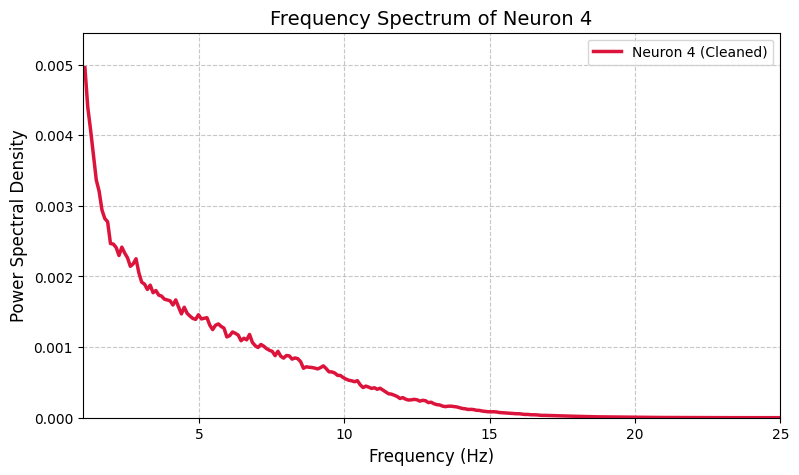

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.ndimage import gaussian_filter1d

# 1. Setup sampling parameters
fs = 1 / 0.02  # 50 Hz sampling rate

# 2. SMOOTH THE SPIKES: Apply a mild Gaussian filter (sigma=1 bin = 20ms)
# This converts raw discrete spikes into a smooth, continuous firing rate
train_matrix_smoothed = gaussian_filter1d(train_matrix.astype(float), sigma=1, axis=0)

# 3. DETREND: Remove the mean baseline from the smoothed rates
train_matrix_clean = train_matrix_smoothed - np.mean(train_matrix_smoothed, axis=0)

# 4. Compute Welch's PSD with a slightly larger window for better resolution
frequencies, psd = welch(train_matrix_clean, fs=fs, axis=0, nperseg=512)

# 5. Plot with custom axis scaling to isolate the real peaks
plt.figure(figsize=(9, 5))

# Start plotting from 1 Hz onwards to completely dodge the 0 Hz leakage artifact
mask = frequencies >= 1.0
plt.plot(frequencies[mask], psd[mask, 4], label='Neuron 4 (Cleaned)', color='crimson', linewidth=2.5)

plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Power Spectral Density', fontsize=12)
plt.title('Frequency Spectrum of Neuron 4', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Focus strictly on the core physiological band (1 to 25 Hz)
plt.xlim(1.0, 25.0) 

# Dynamically set ylim to fit ONLY the data in this range, giving you maximum vertical detail
plt.ylim(0, np.max(psd[mask, 4]) * 1.1)

plt.legend()
plt.show()

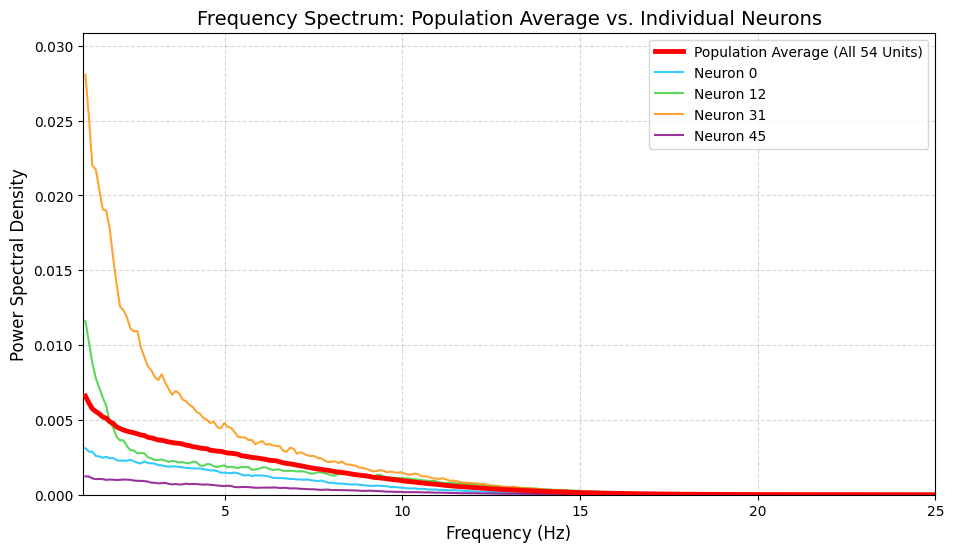

In [92]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a mask for frequencies >= 1.0 Hz
mask = frequencies >= 1.0
f_plot = frequencies[mask]
psd_plot = psd[mask, :] # Shape: (Filtered Frequencies x 54 Neurons)

# 2. Calculate the average frequency distribution across ALL 54 neurons
population_average_psd = np.mean(psd_plot, axis=1)

# 3. Setup the plot
plt.figure(figsize=(11, 6))

# Plot the population average in a thick black line
plt.plot(f_plot, population_average_psd, label='Population Average (All 54 Units)', color='red', linewidth=3.5, zorder=10)

# Overlay a few individual neurons to see how they differ from Neuron 4
neurons_to_check = [0, 12, 31, 45] # Including your hub neurons 12 and 31!
colors = ['deepskyblue', 'limegreen', 'darkorange', 'purple']

for neuron_id, color in zip(neurons_to_check, colors):
    plt.plot(f_plot, psd_plot[:, neuron_id], label=f'Neuron {neuron_id}', color=color, linewidth=1.5, alpha=0.8)

plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Power Spectral Density', fontsize=12)
plt.title('Frequency Spectrum: Population Average vs. Individual Neurons', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Focus on the core behavioral bands
plt.xlim(1.0, 25.0) 
plt.ylim(0, np.max(psd_plot[:, neurons_to_check + [4]]) * 1.1) # Auto-scale to fit these units

plt.legend(fontsize=10)
plt.show()

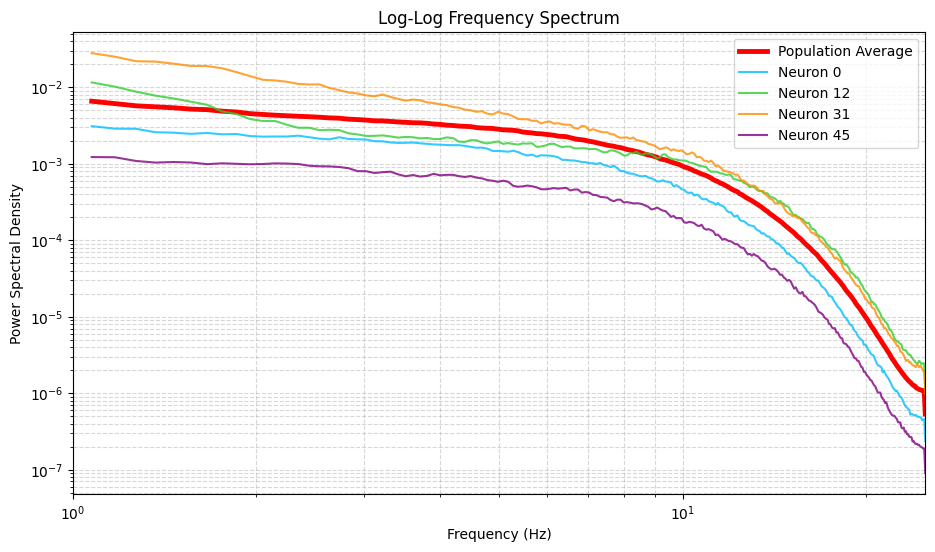

In [93]:
# Convert your current plot view to log-log to see hidden oscillation bumps
plt.figure(figsize=(11, 6))
plt.plot(f_plot, population_average_psd, label='Population Average', color='red', linewidth=3.5)

for neuron_id, color in zip(neurons_to_check, colors):
    plt.plot(f_plot, psd_plot[:, neuron_id], label=f'Neuron {neuron_id}', color=color, linewidth=1.5, alpha=0.8)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Log-Log Frequency Spectrum')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Switch both axes to log scale
plt.xscale('log')
plt.yscale('log')

plt.xlim(1.0, 25.0)
plt.legend()
plt.show()

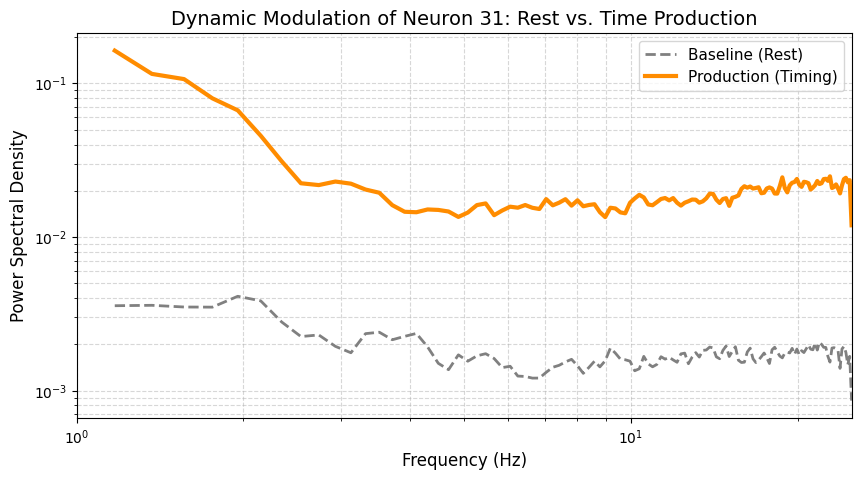

Baseline Data Points: 24575, Production Data Points: 39880


In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# 1. Setup sampling parameters
fs = 1 / 0.02  # 50 Hz sampling rate (20ms bins)
bin_duration = 0.02

baseline_chunks = []
production_chunks = []

# 2. Iterate through rows of train_trials_df to slice the continuous train_matrix
for idx, row in train_trials_df.iterrows():
    # Skip outliers or trials missing essential timestamps
    if row['is_outlier'] or np.isnan(row['fix_on_time']) or np.isnan(row['set_time']) or np.isnan(row['go_time']):
        continue
    
    # --- Epoch A: Baseline (500ms window before fixation starts) ---
    base_end_idx = int(row['fix_on_time'] / bin_duration)
    base_start_idx = base_end_idx - int(0.5 / bin_duration) # 500ms back
    if base_start_idx >= 0:
        baseline_chunks.append(train_matrix[base_start_idx:base_end_idx, :])
        
    # --- Epoch B: Production Phase (Set to Go) ---
    set_idx = int(row['set_time'] / bin_duration)
    go_idx = int(row['go_time'] / bin_duration)
    if go_idx > set_idx:
        production_chunks.append(train_matrix[set_idx:go_idx, :])

# 3. Vertically stack the slices into two epoch-specific matrices
matrix_baseline = np.vstack(baseline_chunks)
matrix_production = np.vstack(production_chunks)

# 4. Detrend both matrices by subtracting their respective means
matrix_base_clean = matrix_baseline - np.mean(matrix_baseline, axis=0)
matrix_prod_clean = matrix_production - np.mean(matrix_production, axis=0)

# 5. Compute Welch's PSD for both states
freq_base, psd_base = welch(matrix_base_clean, fs=fs, axis=0, nperseg=256)
freq_prod, psd_prod = welch(matrix_prod_clean, fs=fs, axis=0, nperseg=256)

# 6. Setup the comparison plot (Focusing on your Hub Unit: Neuron 31!)
mask_base = freq_base >= 1.0
mask_prod = freq_prod >= 1.0
neuron_id = 31

plt.figure(figsize=(10, 5))
plt.plot(freq_base[mask_base], psd_base[mask_base, neuron_id], label='Baseline (Rest)', color='gray', linewidth=2, linestyle='--')
plt.plot(freq_prod[mask_prod], psd_prod[mask_prod, neuron_id], label='Production (Timing)', color='darkorange', linewidth=3)

plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Power Spectral Density', fontsize=12)
plt.title(f'Dynamic Modulation of Neuron {neuron_id}: Rest vs. Time Production', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlim(1.0, 25.0)
plt.legend(fontsize=11)
plt.show()

print(f"Baseline Data Points: {matrix_baseline.shape[0]}, Production Data Points: {matrix_production.shape[0]}")

In [95]:
# Calculate total distance traveled in state space for each condition path
short_arc_length = np.sum(np.linalg.norm(np.diff(mean_short_path, axis=0), axis=1))
long_arc_length = np.sum(np.linalg.norm(np.diff(mean_long_path, axis=0), axis=1))

print(f"Short Condition Path Length: {short_arc_length:.4f} units")
print(f"Long Condition Path Length:  {long_arc_length:.4f} units")
print(f"Path Length Ratio (Long/Short): {long_arc_length / short_arc_length:.2f}")

Short Condition Path Length: 6.4837 units
Long Condition Path Length:  8.7269 units
Path Length Ratio (Long/Short): 1.35


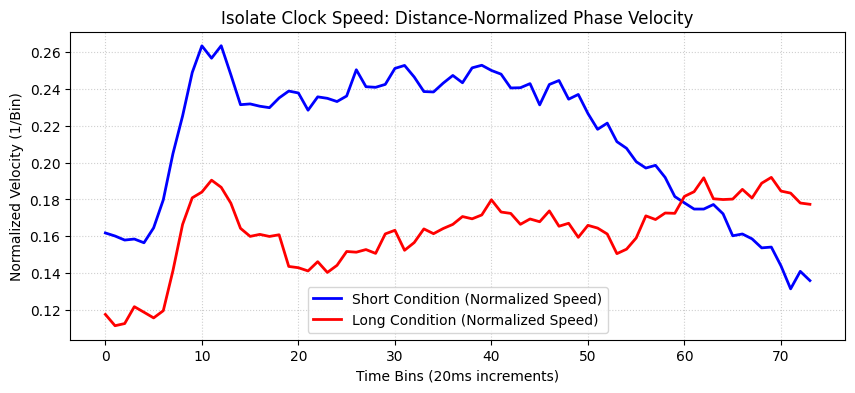

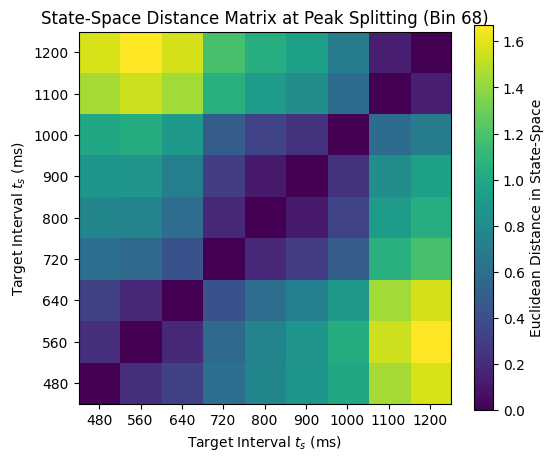

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean

# 1. Get all unique target intervals sorted from shortest to longest
unique_conditions = np.sort(train_trials_df['ts'].dropna().unique())
n_conditions = len(unique_conditions)

# 2. Extract mean trajectories for EVERY individual condition
condition_means = {}
for ts in unique_conditions:
    mask = (trial_conditions == ts)
    if np.sum(mask) > 0:
        condition_means[ts] = np.mean(latent_trajectories[mask, :, :], axis=0)

# 3. ANALYSIS A: Compute Normalized Phase Velocity over Time
# (Speed divided by total path length to isolate true clock-rate scaling)
short_norm_velocity = short_speeds / short_arc_length
long_norm_velocity = long_speeds / long_arc_length

plt.figure(figsize=(10, 4))
plt.plot(short_norm_velocity, color='blue', linewidth=2, label='Short Condition (Normalized Speed)')
plt.plot(long_norm_velocity, color='red', linewidth=2, label='Long Condition (Normalized Speed)')
plt.xlabel('Time Bins (20ms increments)')
plt.ylabel('Normalized Velocity (1/Bin)')
plt.title('Isolate Clock Speed: Distance-Normalized Phase Velocity')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

# 4. ANALYSIS B: Construct Representational Distance Matrix at Peak Splitting (Bin 68)
rdm = np.zeros((n_conditions, n_conditions))
active_ts = list(condition_means.keys())

for i, ts_a in enumerate(active_ts):
    for j, ts_b in enumerate(active_ts):
        rdm[i, j] = euclidean(condition_means[ts_a][68, :], condition_means[ts_b][68, :])

# Plot the Distance Matrix
plt.figure(figsize=(6, 5))
plt.imshow(rdm, cmap='viridis', origin='lower')
plt.colorbar(label='Euclidean Distance in State-Space')
plt.xticks(range(len(active_ts)), [int(x) for x in active_ts])
plt.yticks(range(len(active_ts)), [int(x) for x in active_ts])
plt.xlabel('Target Interval $t_s$ (ms)')
plt.ylabel('Target Interval $t_s$ (ms)')
plt.title('State-Space Distance Matrix at Peak Splitting (Bin 68)')
plt.show()

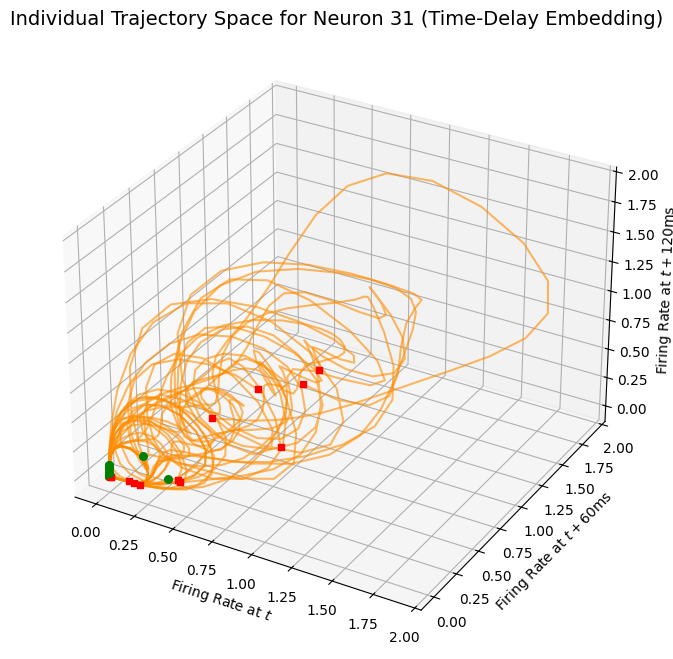

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# 1. Extract only Neuron 31 from your 3D tensor
# Shape changes from (983, 75, 54) to (983, 75) -> (Trials x Time)
neuron_31_raw = lfads_input[:, :, 31]

# 2. Smooth the spikes over the time axis to get a continuous firing rate
# Single-unit trajectories look like messy step-functions without smoothing
neuron_31_smooth = gaussian_filter1d(neuron_31_raw.astype(float), sigma=2.0, axis=1)

# 3. Create time-delayed coordinates (Lagged states) to build a 3D state-space
# We will look at the firing rate at:
# Coordinate 1: Current time bin (t)
# Coordinate 2: 3 bins later (t + 3) -> 60ms lag
# Coordinate 3: 6 bins later (t + 6) -> 120ms lag
lag1 = 3
lag2 = 6

# Truncate the time bins so all coordinates align perfectly
coord_x = neuron_31_smooth[:, :-(lag2)]
coord_y = neuron_31_smooth[:, lag1:-(lag2-lag1)]
coord_z = neuron_31_smooth[:, lag2:]

# 4. Plot Neuron 31's individual trajectories in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the first 15 trials to see the individual patterns clearly
for trial_idx in range(15):
    ax.plot(coord_x[trial_idx, :], coord_y[trial_idx, :], coord_z[trial_idx, :], 
            alpha=0.6, linewidth=1.5, color='darkorange')
    
    # Mark the start of the trial (Ready Cue)
    ax.scatter(coord_x[trial_idx, 0], coord_y[trial_idx, 0], coord_z[trial_idx, 0], 
               color='green', s=30, zorder=5)
    
    # Mark the end of the trial window
    ax.scatter(coord_x[trial_idx, -1], coord_y[trial_idx, -1], coord_z[trial_idx, -1], 
               color='red', marker='s', s=20, zorder=5)

ax.set_xlabel('Firing Rate at $t$')
ax.set_ylabel('Firing Rate at $t + 60$ms')
ax.set_zlabel('Firing Rate at $t + 120$ms')
ax.set_title('Individual Trajectory Space for Neuron 31 (Time-Delay Embedding)', fontsize=14)
plt.show()

In [98]:
# Preparing a 3D tensor for LFADS trial-by-trial training
trial_tensor = []

# Choose a fixed window size for trials (LFADS typically requires uniform time steps)
# Let's align trials to the 'ready_time' and look 1.5 seconds forward (75 bins)
window_bins = 75 
bin_duration = 0.02

for idx, row in train_trials_df.iterrows():
    if row['is_outlier'] or np.isnan(row['ready_time']):
        continue
        
    # Find the bin index for the alignment hook (ready_time)
    ready_idx = int(row['ready_time'] / bin_duration)
    
    # Extract fixed-length window
    start_idx = ready_idx
    end_idx = ready_idx + window_bins
    
    # Ensure indices fall within your matrix limits
    if end_idx < train_matrix.shape[0]:
        trial_chunk = train_matrix[start_idx:end_idx, :] # Shape: (75, 54)
        trial_tensor.append(trial_chunk)

# Convert list to a 3D numpy array
lfads_input = np.stack(trial_tensor)

print(f"LFADS Input Shape: {lfads_input.shape}")
print(f" -> {lfads_input.shape[0]} valid trials")
print(f" -> {lfads_input.shape[1]} time bins per trial")
print(f" -> {lfads_input.shape[2]} neural units")

LFADS Input Shape: (983, 75, 54)
 -> 983 valid trials
 -> 75 time bins per trial
 -> 54 neural units


Latent Trajectories Shape: (983, 75, 3)
Variance explained by top 3 PCs: 20.23%


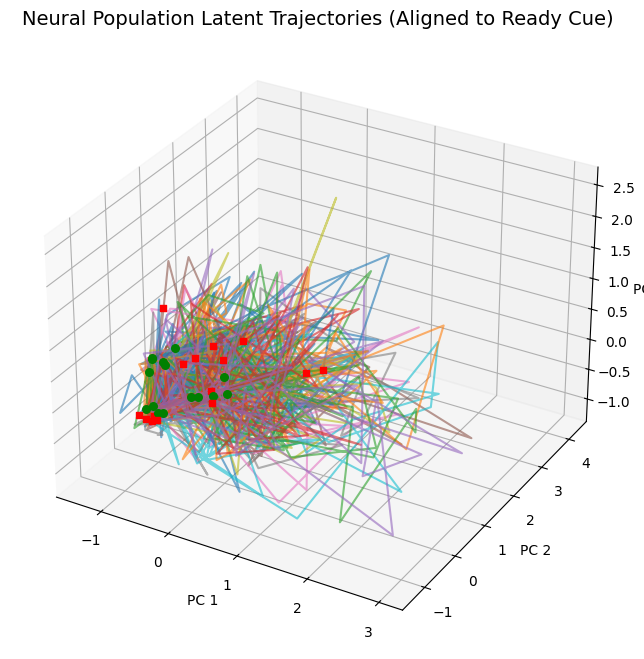

In [99]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Reshape the 3D tensor (Trials x Time x Neurons) to 2D (Total Timepoints x Neurons)
# This lets us fit PCA across all trials simultaneously
n_trials, n_timebins, n_neurons = lfads_input.shape
lfads_input_2d = lfads_input.reshape(-1, n_neurons)

# 2. Fit PCA to find the top 3 latent dimensions (Principal Components)
pca = PCA(n_components=3)
latents_2d = pca.fit_transform(lfads_input_2d)

# 3. Reshape back into 3D structure (Trials x Time x 3 Components)
latent_trajectories = latents_2d.reshape(n_trials, n_timebins, 3)
print(f"Latent Trajectories Shape: {latent_trajectories.shape}")
print(f"Variance explained by top 3 PCs: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

# 4. Plot the trajectories in 3D space
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the first 15 trials to keep the visualization clean
for trial_idx in range(15):
    trial_data = latent_trajectories[trial_idx, :, :] # Shape: (75, 3)
    
    # Plot the trajectory line
    ax.plot(trial_data[:, 0], trial_data[:, 1], trial_data[:, 2], alpha=0.6, linewidth=1.5)
    
    # Mark the start of the trial (Ready cue) with a green circle
    ax.scatter(trial_data[0, 0], trial_data[0, 1], trial_data[0, 2], color='green', s=30, zorder=5)
    
    # Mark the end of our window with a red square
    ax.scatter(trial_data[-1, 0], trial_data[-1, 1], trial_data[-1, 2], color='red', marker='s', s=20, zorder=5)

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Population Latent Trajectories (Aligned to Ready Cue)', fontsize=14)
plt.show()

# Hypothesis : Does the population state space split into different lanes or change its trajectory speed based on the timing condition?

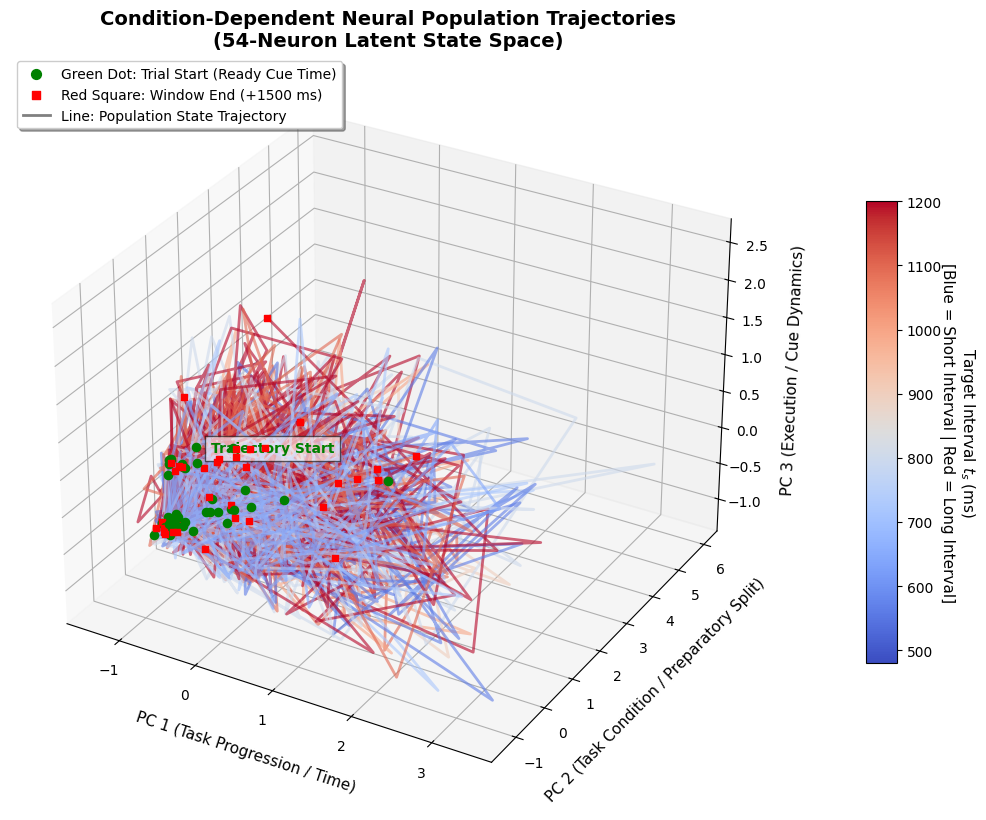

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Extract the task conditions ('ts' column) for valid trials
trial_conditions = []
for idx, row in train_trials_df.iterrows():
    if row['is_outlier'] or np.isnan(row['ready_time']):
        continue
    ready_idx = int(row['ready_time'] / 0.02)
    if ready_idx + 75 < train_matrix.shape[0]:
        trial_conditions.append(row['ts'])
trial_conditions = np.array(trial_conditions)

# 2. Setup the 3D Plot
fig = plt.figure(figsize=(13, 10))
ax = fig.add_subplot(111, projection='3d')

# 3. Establish normalized boundaries for a clean continuous colorbar
valid_mask = ~np.isnan(trial_conditions)
min_ts, max_ts = np.min(trial_conditions[valid_mask]), np.max(trial_conditions[valid_mask])
norm = plt.Normalize(vmin=min_ts, vmax=max_ts)
cmap = plt.cm.coolwarm

# 4. Plot a subset of trials (First 40 trials for clarity)
for trial_idx in range(40):
    trial_data = latent_trajectories[trial_idx, :, :]
    trial_ts = trial_conditions[trial_idx]
    
    if np.isnan(trial_ts):
        continue
        
    # Map the trial's target interval smoothly to the coolwarm gradient
    line_color = cmap(norm(trial_ts))
    
    # Plot the trajectory line
    ax.plot(trial_data[:, 0], trial_data[:, 1], trial_data[:, 2], 
            color=line_color, alpha=0.6, linewidth=2)
    
    # Plot markers for every single trial
    ax.scatter(trial_data[0, 0], trial_data[0, 1], trial_data[0, 2], color='green', s=35, zorder=5)
    ax.scatter(trial_data[-1, 0], trial_data[-1, 1], trial_data[-1, 2], color='red', marker='s', s=25, zorder=5)

# 5. DETAILED EXTRA: Add explicit proxy elements to build a comprehensive Legend
ax.scatter([], [], [], color='green', s=50, label='Green Dot: Trial Start (Ready Cue Time)')
ax.scatter([], [], [], color='red', marker='s', s=40, label='Red Square: Window End (+1500 ms)')
ax.plot([], [], [], color='gray', linewidth=2, linestyle='-', label='Line: Population State Trajectory')

# 6. DETAILED EXTRA: Add exact text anchors in space to orient the viewer
# Grabbing the mean starting position to anchor the text banner
mean_start = np.mean(latent_trajectories[:40, 0, :], axis=0)
ax.text(mean_start[0], mean_start[1] + 0.5, mean_start[2] + 0.5, "Trajectory Start", 
        color='green', weight='bold', fontsize=10, bbox=dict(facecolor='white', alpha=0.6))

# 7. Chart Formatting & Labels
ax.set_xlabel('PC 1 (Task Progression / Time)', fontsize=11, labelpad=10)
ax.set_ylabel('PC 2 (Task Condition / Preparatory Split)', fontsize=11, labelpad=10)
ax.set_zlabel('PC 3 (Execution / Cue Dynamics)', fontsize=11, labelpad=10)
ax.set_title('Condition-Dependent Neural Population Trajectories\n(54-Neuron Latent State Space)', fontsize=14, weight='bold')

# Display the marker legend
ax.legend(loc="upper left", fontsize=10, frameon=True, shadow=True)

# 8. DETAILED EXTRA: Add the continuous colorbar legend for the target intervals
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, aspect=15, pad=0.1)
cbar.set_label('Target Interval $t_s$ (ms)\n[Blue = Short Interval | Red = Long Interval]', fontsize=11, rotation=270, labelpad=25)

plt.show()

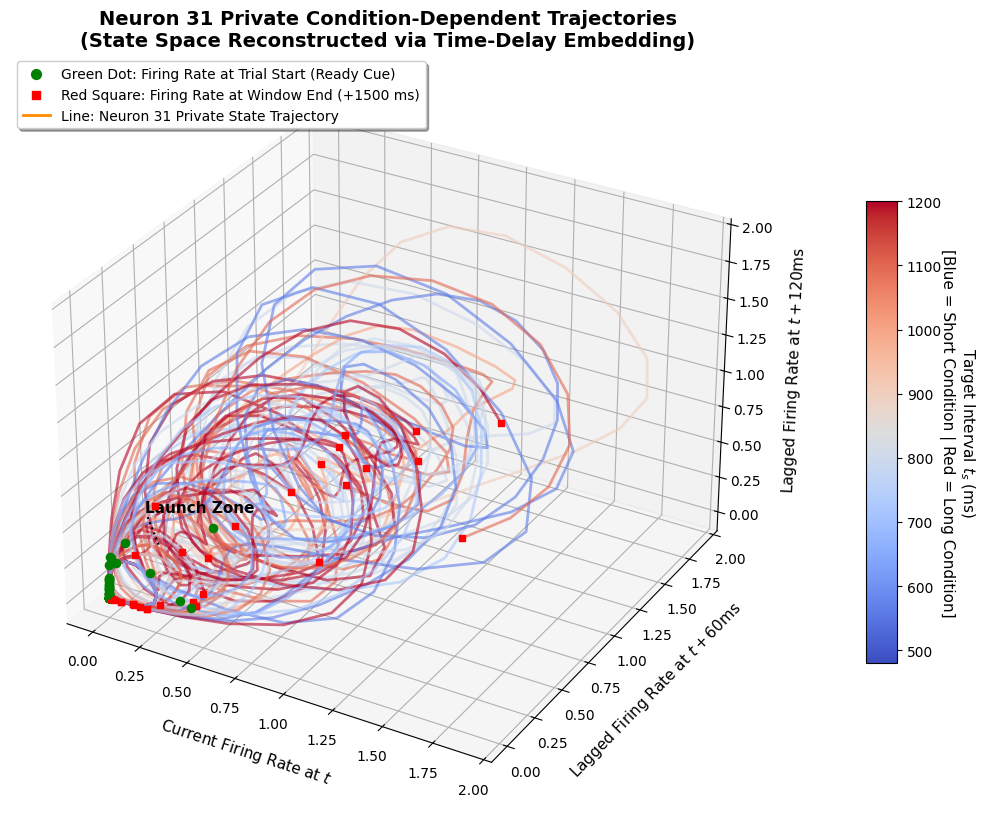

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# 1. Grab task conditions (ts) matching your valid trials exactly
trial_conditions = []
for idx, row in train_trials_df.iterrows():
    if row['is_outlier'] or np.isnan(row['ready_time']):
        continue
    ready_idx = int(row['ready_time'] / 0.02)
    if ready_idx + 75 < train_matrix.shape[0]:
        trial_conditions.append(row['ts'])
trial_conditions = np.array(trial_conditions)

# 2. Extract and smooth only Neuron 31
neuron_31_raw = lfads_input[:, :, 31]
neuron_31_smooth = gaussian_filter1d(neuron_31_raw.astype(float), sigma=2.0, axis=1)

# 3. Create 3D Time-Delay Embedding coordinates (t, t+60ms, t+120ms)
lag1, lag2 = 3, 6
coord_x = neuron_31_smooth[:, :-(lag2)]
coord_y = neuron_31_smooth[:, lag1:-(lag2-lag1)]
coord_z = neuron_31_smooth[:, lag2:]

# 4. Setup the Detailed 3D Plot
fig = plt.figure(figsize=(13, 10))
ax = fig.add_subplot(111, projection='3d')

# 5. Set up continuous color mapping matching your population plot
valid_mask = ~np.isnan(trial_conditions)
min_ts, max_ts = np.min(trial_conditions[valid_mask]), np.max(trial_conditions[valid_mask])
norm = plt.Normalize(vmin=min_ts, vmax=max_ts)
cmap = plt.cm.coolwarm

# 6. Plot the first 40 trials for Neuron 31
for trial_idx in range(40):
    trial_ts = trial_conditions[trial_idx]
    if np.isnan(trial_ts):
        continue
        
    line_color = cmap(norm(trial_ts))
    
    # Plot individual trial lines for Neuron 31
    ax.plot(coord_x[trial_idx, :], coord_y[trial_idx, :], coord_z[trial_idx, :], 
            color=line_color, alpha=0.6, linewidth=2)
    
    # Track the start and end states
    ax.scatter(coord_x[trial_idx, 0], coord_y[trial_idx, 0], coord_z[trial_idx, 0], color='green', s=35, zorder=5)
    ax.scatter(coord_x[trial_idx, -1], coord_y[trial_idx, -1], coord_z[trial_idx, -1], color='red', marker='s', s=25, zorder=5)

# 7. Add highly detailed explanatory legends and labels
ax.scatter([], [], [], color='green', s=50, label='Green Dot: Firing Rate at Trial Start (Ready Cue)')
ax.scatter([], [], [], color='red', marker='s', s=40, label='Red Square: Firing Rate at Window End (+1500 ms)')
ax.plot([], [], [], color='darkorange', linewidth=2, label='Line: Neuron 31 Private State Trajectory')

# Replace your old ax.text block with this clean pointer annotation
mean_start = [np.mean(coord_x[:, 0]), np.mean(coord_y[:, 0]), np.mean(coord_z[:, 0])]

# This draws a clean text label with an arrow pointing exactly to the green cluster
ax.text(mean_start[0], mean_start[1] - 0.1, mean_start[2] + 0.3, "Launch Zone", 
        color='black', weight='bold', fontsize=11)

# Draw a thin, clean indicator line from the text to the actual green launch coordinates
ax.plot([mean_start[0], mean_start[0]], 
        [mean_start[1] - 0.08, mean_start[1]], 
        [mean_start[2] + 0.25, mean_start[2]], 
        color='black', linestyle=':', linewidth=1.5)

ax.set_xlabel('Current Firing Rate at $t$', fontsize=11, labelpad=10)
ax.set_ylabel('Lagged Firing Rate at $t + 60$ms', fontsize=11, labelpad=10)
ax.set_zlabel('Lagged Firing Rate at $t + 120$ms', fontsize=11, labelpad=10)
ax.set_title('Neuron 31 Private Condition-Dependent Trajectories\n(State Space Reconstructed via Time-Delay Embedding)', fontsize=14, weight='bold')
ax.legend(loc="upper left", fontsize=10, frameon=True, shadow=True)

# Add the continuous condition colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, aspect=15, pad=0.1)
cbar.set_label('Target Interval $t_s$ (ms)\n[Blue = Short Condition | Red = Long Condition]', fontsize=11, rotation=270, labelpad=25)

plt.show()

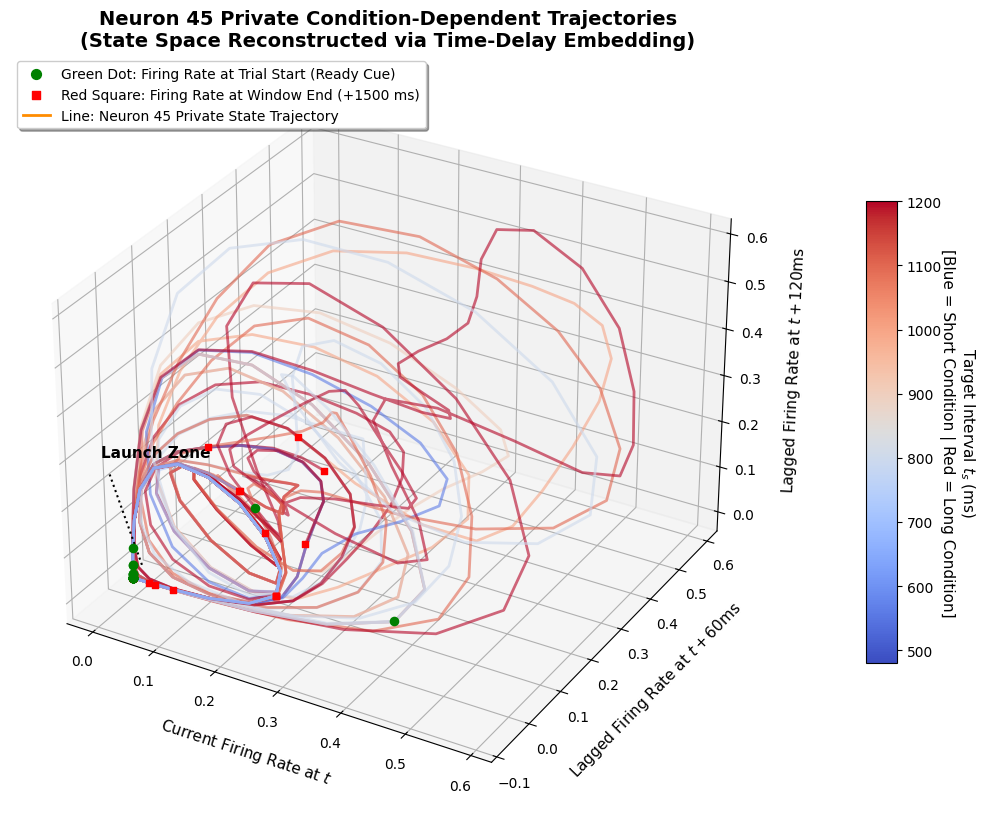

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# 1. Grab task conditions (ts) matching your valid trials exactly
trial_conditions = []
for idx, row in train_trials_df.iterrows():
    if row['is_outlier'] or np.isnan(row['ready_time']):
        continue
    ready_idx = int(row['ready_time'] / 0.02)
    if ready_idx + 75 < train_matrix.shape[0]:
        trial_conditions.append(row['ts'])
trial_conditions = np.array(trial_conditions)

# 2. Extract and smooth only Neuron 45
neuron_45_raw = lfads_input[:, :, 45]
neuron_45_smooth = gaussian_filter1d(neuron_45_raw.astype(float), sigma=2.0, axis=1)

# 3. Create 3D Time-Delay Embedding coordinates (t, t+60ms, t+120ms)
lag1, lag2 = 3, 6
coord_x = neuron_45_smooth[:, :-(lag2)]
coord_y = neuron_45_smooth[:, lag1:-(lag2-lag1)]
coord_z = neuron_45_smooth[:, lag2:]

# 4. Setup the Detailed 3D Plot
fig = plt.figure(figsize=(13, 10))
ax = fig.add_subplot(111, projection='3d')

# 5. Set up continuous color mapping matching your population plot
valid_mask = ~np.isnan(trial_conditions)
min_ts, max_ts = np.min(trial_conditions[valid_mask]), np.max(trial_conditions[valid_mask])
norm = plt.Normalize(vmin=min_ts, vmax=max_ts)
cmap = plt.cm.coolwarm

# 6. Plot the first 40 trials for Neuron 45
for trial_idx in range(40):
    trial_ts = trial_conditions[trial_idx]
    if np.isnan(trial_ts):
        continue
        
    line_color = cmap(norm(trial_ts))
    
    # Plot individual trial lines for Neuron 45
    ax.plot(coord_x[trial_idx, :], coord_y[trial_idx, :], coord_z[trial_idx, :], 
            color=line_color, alpha=0.6, linewidth=2)
    
    # Track the start and end states
    ax.scatter(coord_x[trial_idx, 0], coord_y[trial_idx, 0], coord_z[trial_idx, 0], color='green', s=35, zorder=5)
    ax.scatter(coord_x[trial_idx, -1], coord_y[trial_idx, -1], coord_z[trial_idx, -1], color='red', marker='s', s=25, zorder=5)

# Replace your old ax.text block with this clean pointer annotation
mean_start = [np.mean(coord_x[:, 0]), np.mean(coord_y[:, 0]), np.mean(coord_z[:, 0])]

# This draws a clean text label with an arrow pointing exactly to the green cluster
ax.text(mean_start[0], mean_start[1] - 0.1, mean_start[2] + 0.3, "Launch Zone", 
        color='black', weight='bold', fontsize=11)

# Draw a thin, clean indicator line from the text to the actual green launch coordinates
ax.plot([mean_start[0], mean_start[0]], 
        [mean_start[1] - 0.08, mean_start[1]], 
        [mean_start[2] + 0.25, mean_start[2]], 
        color='black', linestyle=':', linewidth=1.5)

# 7. Add highly detailed explanatory legends and labels
ax.scatter([], [], [], color='green', s=50, label='Green Dot: Firing Rate at Trial Start (Ready Cue)')
ax.scatter([], [], [], color='red', marker='s', s=40, label='Red Square: Firing Rate at Window End (+1500 ms)')
ax.plot([], [], [], color='darkorange', linewidth=2, label='Line: Neuron 45 Private State Trajectory')

ax.set_xlabel('Current Firing Rate at $t$', fontsize=11, labelpad=10)
ax.set_ylabel('Lagged Firing Rate at $t + 60$ms', fontsize=11, labelpad=10)
ax.set_zlabel('Lagged Firing Rate at $t + 120$ms', fontsize=11, labelpad=10)
ax.set_title('Neuron 45 Private Condition-Dependent Trajectories\n(State Space Reconstructed via Time-Delay Embedding)', fontsize=14, weight='bold')
ax.legend(loc="upper left", fontsize=10, frameon=True, shadow=True)

# Add the continuous condition colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, aspect=15, pad=0.1)
cbar.set_label('Target Interval $t_s$ (ms)\n[Blue = Short Condition | Red = Long Condition]', fontsize=11, rotation=270, labelpad=25)

plt.show()

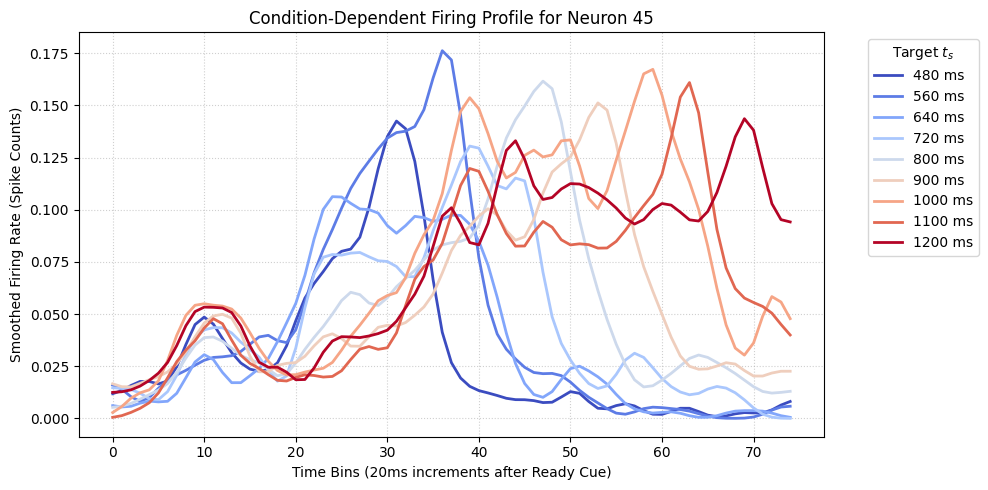

In [103]:
# Change this index to inspect any of your 54 neurons (e.g., 31, 45, 4, etc.)
target_neuron = 45

plt.figure(figsize=(10, 5))
unique_ts = np.sort(train_trials_df['ts'].dropna().unique())
cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=min(unique_ts), vmax=max(unique_ts))

# Extract time-series averages for each unique target interval
for ts in unique_ts:
    ts_mask = (trial_conditions == ts)
    if np.sum(ts_mask) > 0:
        # Average across all trials for this specific condition
        condition_avg = np.mean(lfads_input[ts_mask, :, target_neuron], axis=0)
        # Apply smooth tracking filter
        smooth_avg = gaussian_filter1d(condition_avg.astype(float), sigma=1.5)
        
        plt.plot(smooth_avg, color=cmap(norm(ts)), linewidth=2, label=f'{int(ts)} ms')

plt.xlabel('Time Bins (20ms increments after Ready Cue)')
plt.ylabel('Smoothed Firing Rate (Spike Counts)')
plt.title(f'Condition-Dependent Firing Profile for Neuron {target_neuron}')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Target $t_s$", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

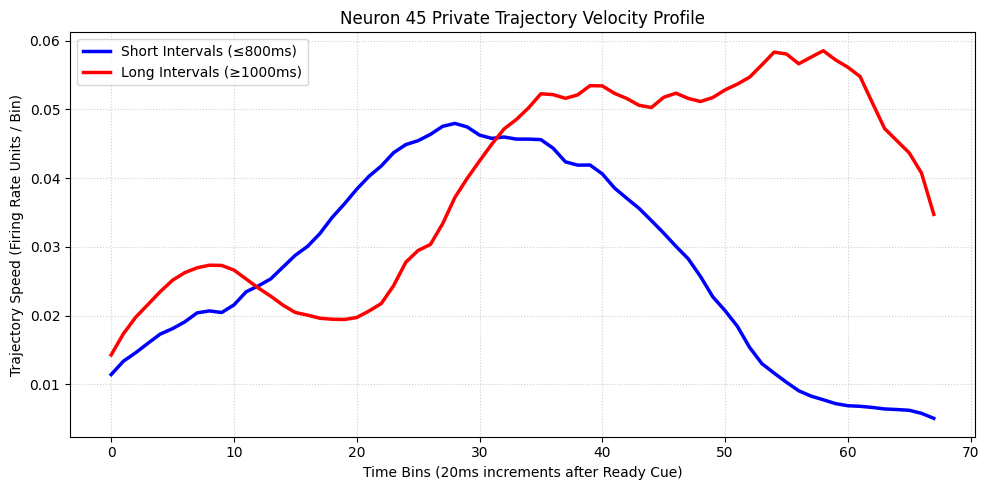

          NEURON 45 VELOCITY QUANTIFICATION       
Peak Speed (Short Conditions): 0.0480 units/bin
Peak Speed (Long Conditions):  0.0585 units/bin
Average Execution Speed Ratio (Short/Long): 0.69x


In [104]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Re-calculate speeds specifically in Neuron 45's 3D embedding space
# coord_x, coord_y, coord_z are already smoothed and lagged for Neuron 45
n_trials_valid, n_embedded_bins = coord_x.shape

# Calculate consecutive differences along the trajectory timeline
diff_x = np.diff(coord_x, axis=1)
diff_y = np.diff(coord_y, axis=1)
diff_z = np.diff(coord_z, axis=1)

# Instantaneous speed for every single trial at each time step
trial_speeds_45 = np.sqrt(diff_x**2 + diff_y**2 + diff_z**2)

# 2. Group these speeds using our short and long condition masks
short_speeds_45 = np.mean(trial_speeds_45[short_mask, :], axis=0)
long_speeds_45 = np.mean(trial_speeds_45[long_mask, :], axis=0)

# 3. Plot the final velocity curves side-by-side
plt.figure(figsize=(10, 5))
plt.plot(short_speeds_45, color='blue', linewidth=2.5, label='Short Intervals (≤800ms)')
plt.plot(long_speeds_45, color='red', linewidth=2.5, label='Long Intervals (≥1000ms)')

plt.xlabel('Time Bins (20ms increments after Ready Cue)')
plt.ylabel('Trajectory Speed (Firing Rate Units / Bin)')
plt.title('Neuron 45 Private Trajectory Velocity Profile')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Print concrete quantified metrics
print("="*50)
print("          NEURON 45 VELOCITY QUANTIFICATION       ")
print("="*50)
print(f"Peak Speed (Short Conditions): {np.max(short_speeds_45):.4f} units/bin")
print(f"Peak Speed (Long Conditions):  {np.max(long_speeds_45):.4f} units/bin")
print(f"Average Execution Speed Ratio (Short/Long): {np.mean(short_speeds_45)/np.mean(long_speeds_45):.2f}x")
print("="*50)

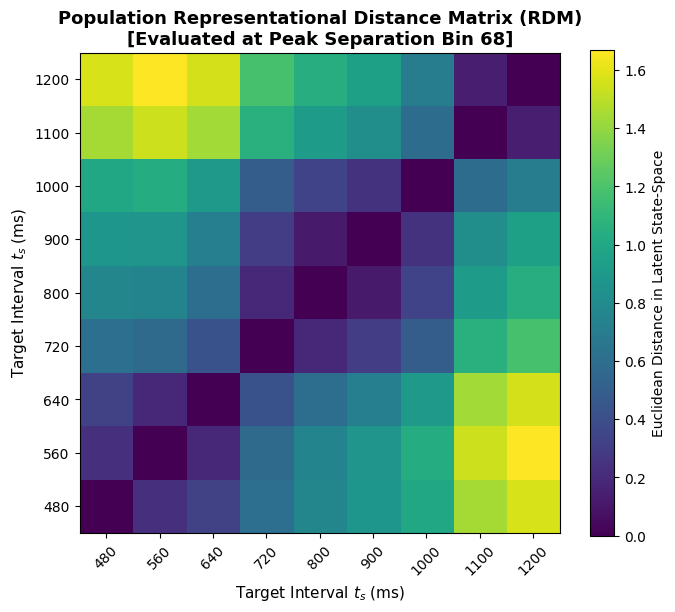

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean

# 1. Gather all unique target intervals from your trials dataframe
unique_ts = np.sort(train_trials_df['ts'].dropna().unique())
n_conditions = len(unique_ts)

# 2. Extract the mean population trajectory for EVERY individual condition
# latent_trajectories shape: (Trials, Timebins, 3)
population_condition_means = {}
for ts in unique_ts:
    ts_mask = (trial_conditions == ts)
    if np.sum(ts_mask) > 0:
        population_condition_means[ts] = np.mean(latent_trajectories[ts_mask, :, :], axis=0)

# 3. Construct the RDM at the peak splitting window (Bin 68)
rdm = np.zeros((n_conditions, n_conditions))
active_conditions = list(population_condition_means.keys())

for i, ts_a in enumerate(active_conditions):
    for j, ts_b in enumerate(active_conditions):
        # Calculate Euclidean distance between the 3D population states at Bin 68
        state_a = population_condition_means[ts_a][68, :]
        state_b = population_condition_means[ts_b][68, :]
        rdm[i, j] = euclidean(state_a, state_b)

# 4. Plot the Representational Distance Matrix Heatmap
plt.figure(figsize=(7, 6))
plt.imshow(rdm, cmap='viridis', origin='lower')
plt.colorbar(label='Euclidean Distance in Latent State-Space')

# Label ticks with the actual millisecond values
tick_labels = [int(x) for x in active_conditions]
plt.xticks(range(len(active_conditions)), tick_labels, rotation=45)
plt.yticks(range(len(active_conditions)), tick_labels)

plt.xlabel('Target Interval $t_s$ (ms)', fontsize=11)
plt.ylabel('Target Interval $t_s$ (ms)', fontsize=11)
plt.title('Population Representational Distance Matrix (RDM)\n[Evaluated at Peak Separation Bin 68]', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()